<a href="https://colab.research.google.com/github/wirkleysh/projeto_CD_wirkley/blob/main/Controle_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projeto

In [1]:
!pip install control

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct
import math
import json

In [7]:
# TRATAMENTO DOS DADOS PARA LEVANTAMENTO DA FTMA

# Buscando o arquivo degral.csv no meu drive
caminho_arquivo = r'C:\Users\wirkl\Documents\PlatformIO\Projects\projeto_CD_wirkley\dados_temperatura_67_minutos.json'

try:
  with open(caminho_arquivo, 'r') as f:
    dados_json = json.load(f)
except FileNotFoundError:
  print(f"Erro: '{caminho_arquivo}' não encontrado. Por favor, certifique-se de que o arquivo foi enviado para o Google Drive e a variável 'caminho_arquivo' aponta para o local correto.")
  raise # Relança o erro para parar a execução
except json.JSONDecodeError:
  print(f"Erro: Não foi possível decodificar o arquivo JSON em '{caminho_arquivo}'. Verifique a formatação do arquivo.")
  raise # Relança o erro para parar a execução

k_in = 127

t_orig = []
temperatura_orig = []

for registro in dados_json:
  t_orig.append(float(registro['tempo_segundos']))
  temperatura_orig.append(float(registro['temperatura']))

t_orig = np.array(t_orig)
temperatura_orig = np.array(temperatura_orig)

# Determina a temperatura inicial
T_initial = temperatura_orig[0]

# Desloca os dados de temperatura para que comecem em zero para o cálculo dos parâmetros
temperatura_orig_shifted = temperatura_orig - T_initial
temperatura_orig_shifted = temperatura_orig_shifted / k_in

# Calculando o ganho de regime permanente (k)
tamanho_janela = len(temperatura_orig_shifted)//10
k = np.mean(temperatura_orig_shifted[-tamanho_janela:])
print(f"k = {k:.2f}")

target_value_for_tau = 0.632 * k

idx_for_tau = np.where(temperatura_orig_shifted >= target_value_for_tau)[0]
tau = t_orig[idx_for_tau[0]]
print(f"tau = {tau:.2f} s\n")

t_sim = np.linspace(t_orig.min(), t_orig.max(),len(t_orig))


k = 0.59
tau = 429.00 s



G(s):
 <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.5895
  ---------
  429 s + 1



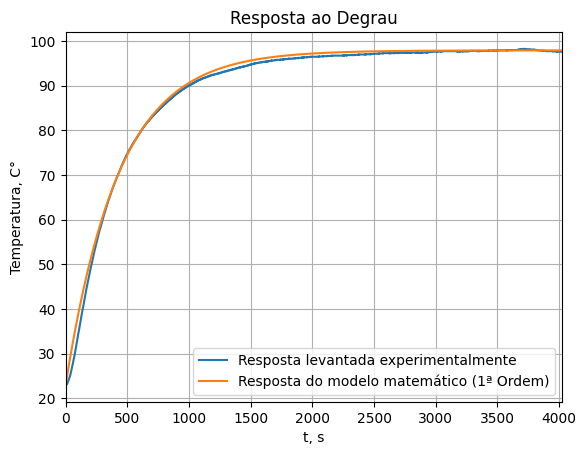

In [8]:
# FUNÇÃO TRANSFERÊNCIA G(s) - Modelo de Primeira Ordem

numG = [k]
denG = [tau, 1]

# Criando a função transferencia G
G = ct.TransferFunction(numG, denG)

print(f"G(s):\n {G}\n")


t_g, temperatura_g_response1 = ct.step_response(G, T=t_sim)
temperatura_g_response = temperatura_g_response1 * k_in
temperatura_g_adjusted = temperatura_g_response + T_initial

plt.figure()
plt.plot(t_orig,temperatura_orig, label='Resposta levantada experimentalmente')
plt.plot(t_g, temperatura_g_adjusted, label='Resposta do modelo matemático (1ª Ordem)')
plt.xlabel('t, s')
plt.ylabel(r'Temperatura, C°')
plt.legend(loc='best')
plt.grid()
plt.xlim(t_orig.min(), t_orig.max())
plt.title('Resposta ao Degrau')
plt.show()


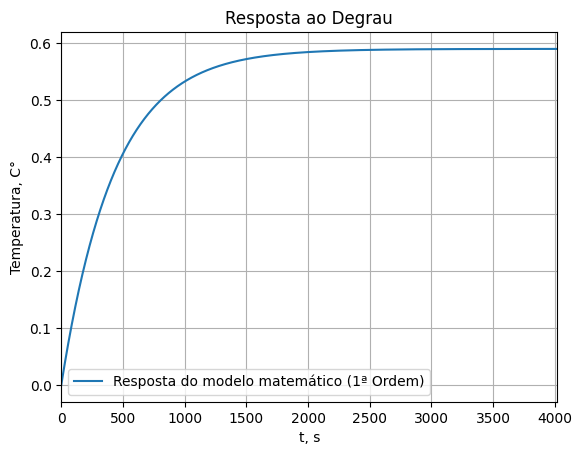

In [9]:
# Plotando apenas a resposta do modelo matemático a um degrau unitário
plt.figure()
plt.plot(t_g, temperatura_g_response1, label='Resposta do modelo matemático (1ª Ordem)')
plt.xlabel('t, s')
plt.ylabel(r'Temperatura, C°')
plt.legend(loc='best')
plt.grid()
plt.xlim(t_orig.min(), t_orig.max())
plt.title('Resposta ao Degrau')
plt.show()


FTD(z):
 <TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 1

  0.001373 z - 0.001373
  ----------------------
  z^2 - 1.998 z + 0.9977



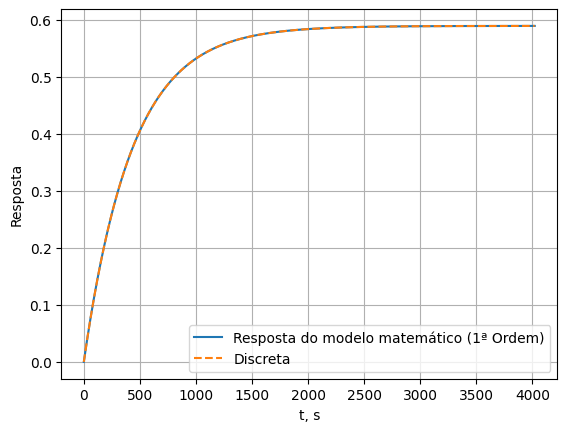

In [13]:
# Plotando a resposta do modelo matemático a um degrau unitário e a resposta discreta
espon_c = np.exp(- 1 / tau)

numZ =  [0, k * (1 - espon_c), k * (- 1 + espon_c)]
denZ = [1, - 1 - espon_c, espon_c]
FTD = ct.TransferFunction(numZ, denZ, dt=1)
print(f"FTD(z):\n {FTD}\n")

t_d, y_d = ct.step_response(FTD, T=np.arange(0, 4020, 1))

plt.figure()
plt.plot(t_g, temperatura_g_response1, label='Resposta do modelo matemático (1ª Ordem)')
plt.plot(t_d, y_d, '--', label='Discreta')
plt.xlabel('t, s')
plt.ylabel('Resposta')
plt.legend()
plt.grid()
plt.show()

C(s):
 <TransferFunction>: sys[36]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = None

  1
  -
  1

FTMF:
 <TransferFunction>: sys[39]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     0.5895
  ------------
  429 s + 1.59



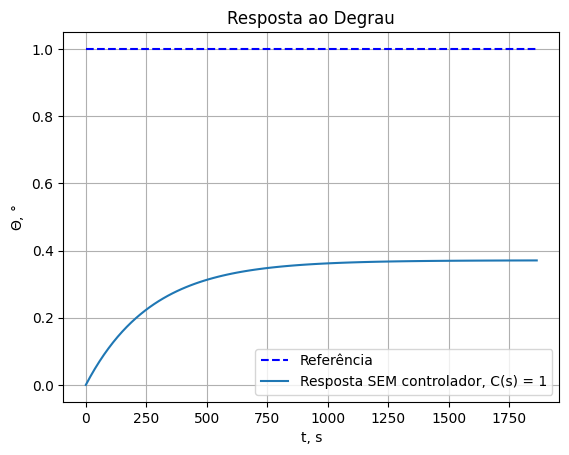

In [33]:
# Controlador: C(s) = 1
C1 = ct.TransferFunction([1],[1])
print(f"C(s):\n {C1}\n")

# FTMF: T(s) = C(s)G(s) / (1 + C(s)G(s))
T1 = ct.feedback(C1 * G)
print(f"FTMF:\n {T1}\n")

t_t1, theta_t1 = ct.step_response(T1)
step = np.ones_like(t_t1) * 1.0 # Define a reference step signal of amplitude 1.0

#Plotando o gráfico
plt.figure()
plt.plot(t_t1, step, 'b--', label='Referência') # Plot the reference step
plt.plot(t_t1, theta_t1, label='Resposta SEM controlador, C(s) = 1')
plt.xlabel('t, s')
plt.ylabel(r'$\Theta$, °')
plt.legend(loc='best')
plt.grid()
plt.xlim()
plt.title('Resposta ao Degrau')
plt.show()

In [16]:
# Calculo das informações da respota ao degrau da T1(s)
step_info_T1 = ct.step_info(T1)

# Extraindo e plotando as especifiçãoes da função ct.step_info
print(f"Tr: {step_info_T1['RiseTime']:.2f} s")
print(f"Tp: {step_info_T1['PeakTime']:.2f} s")
print(f"Mp: {step_info_T1['Overshoot']:.2f}%")
print(f"Ts: {step_info_T1['SettlingTime']:.2f} s (2% tolerancia)")
print(f"theta_rp: {step_info_T1['SteadyStateValue']:.2f}")

# Erro de regime permanente
erro_T1 = 1/(k+1)
print(f"\nErro_RP(matematico): {erro_T1:.2f}")

erro_T1_G = step[-10] - theta_t1[-10]
print(f"Erro_RP(empirico): {erro_T1_G:.2f}")

Tr: 583.78 s
Tp: 1864.34 s
Mp: 0.00%
Ts: 1073.41 s (2% tolerancia)
theta_rp: 0.37

Erro_RP(matematico): 0.63
Erro_RP(empirico): 0.63


In [17]:
# Funções para respostas de funções trigonometricas em graus

def sind(angulo_graus):
  return math.sin(math.radians(angulo_graus))

def cosd(angulo_graus):
  return math.cos(math.radians(angulo_graus))

def tand(angulo_graus):
  return math.tan(math.radians(angulo_graus))

def arctand(valor):
  return math.degrees(math.atan(valor))

In [20]:
# CONTROLADOR PID

# Variaveis
Mp_ftmf = 0.2
Ts_2_ftmf = 47

# Calcular o polos da G(s)
p0 = np.roots(denG)[0]

# Separando a parte real (sigma) e imaginária (w) dos polos
sigma_p0 = p0.real
w_p0 = p0.imag

print(f"s_p0 = {sigma_p0:.4f} {w_p0:.4f}j\n")


# Calculando zeta e wn
zeta_ftmf = -np.log(Mp_ftmf)/np.sqrt(np.pi**2 + np.log(Mp_ftmf)**2)
wn_ftmf = 4/(Ts_2_ftmf*zeta_ftmf)
print(f"zeta_ftmf = {zeta_ftmf:.3f}")
print(f"wn_ftmf = {wn_ftmf:.3f}\n")

# Definir ponto a que o Root Locus deve mapear
sigma_i = - wn_ftmf*zeta_ftmf
w_i = np.sqrt(wn_ftmf**2 - sigma_i**2)
print(f"sigma_i = {sigma_i:.2f}")
print(f"w_i = {w_i:.2f}\n")

# Ponto que o RL precisa mapear
print(f"s = {sigma_i:.2f} + j{w_i:.2f}\n")

s_p0 = -0.0023 0.0000j

zeta_ftmf = 0.456
wn_ftmf = 0.187

sigma_i = -0.09
w_i = 0.17

s = -0.09 + j0.17



In [24]:
# Condição Angular
# theta_pid
alfa_pid = arctand(w_i/np.abs(sigma_i))
theta_pid = 180 - alfa_pid
print(f"theta_pid = {theta_pid:.2f}")

# theta_p0
alfa_p0 = arctand((w_i - w_p0)/(np.abs(sigma_i) - np.abs(sigma_p0)))
theta_p0 = 180 - alfa_p0
print(f"theta_p0 = {theta_p0:.2f}")


# Calculo de theta_z0 e theta_z1
theta_z0 = 80 # atribuindo um valor a theta_z0
theta_z1 = theta_pid + theta_p0 - theta_z0 -180
print(f"theta_z0 = {theta_z0:.2f}")
print(f"theta_z1 = {theta_z1:.2f}\n")

# Calculo de z0 e z1
if theta_z0 > 90:
  x0 = w_i/tand(180 - theta_z0)
  z0 = sigma_i + x0
elif theta_z0 == 90:
  z0 = sigma_i
else:
  x0 = w_i/tand(theta_z0)
  z0 = sigma_i - x0

if theta_z1 > 90:
  x1 = w_i/tand(180 - theta_z1)
  z1 = sigma_i + x1
elif theta_z1 == 90:
  z1 = sigma_i
else:
  x1 = w_i/tand(theta_z1)
  z1 = sigma_i - x1

print(f"z0 = {z0:.2f}")
print(f"z1 = {z1:.2f}\n")

theta_pid = 117.13
theta_p0 = 116.49
theta_z0 = 80.00
theta_z1 = -26.39

z0 = -0.11
z1 = 0.25



In [27]:
# calculo kp, ki e kd
Az0 = np.sqrt(w_i**2 + (sigma_i - z0)**2)
Az1 = np.sqrt(w_i**2 + (sigma_i - z1)**2)

Ap0 = np.sqrt((w_i - w_p0)**2 + (sigma_i - sigma_p0)**2)

Apid = np.sqrt(w_i**2 + sigma_i**2)

kd = (Ap0*Apid)/(numG[0]*Az0*Az1) # Ganho derivativo
kp = np.abs(z0 + z1)*kd # Ganho propocional
ki = np.abs(z0*z1)*kd # Ganho integral

print(f"kp = {kp:.2f}")
print(f"ki = {ki:.2f}")
print(f"kd = {kd:.2f}\n")

# Definir numerador e denominador da função transferencia C(s)
numC = [kd, kp, ki] # Representa numerador de C(s)
denC = [1, 0] # Representa denominador de C(s)
C = ct.tf(numC,denC) # Controlador: C(s)
print(f"C(s):\n {C}\n")

# FTMF: T(s) = C(s)G(s) / (1 + C(s)G(s))
T = ct.feedback(C * G)
print(f"FTMF:\n {T}\n")
print(f'Zeros:\ns = {np.roots(numC)[0]:.2f}\ns = {np.roots(numC)[1]:.2f}')

kp = 0.13
ki = 0.03
kd = 0.93

C(s):
 <TransferFunction>: sys[24]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.932 s^2 + 0.1261 s + 0.02663
  ------------------------------
                s

FTMF:
 <TransferFunction>: sys[27]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.5495 s^2 + 0.07436 s + 0.0157
  -------------------------------
   429.5 s^2 + 1.074 s + 0.0157

Zeros:
s = -0.07+0.15j
s = -0.07-0.15j


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


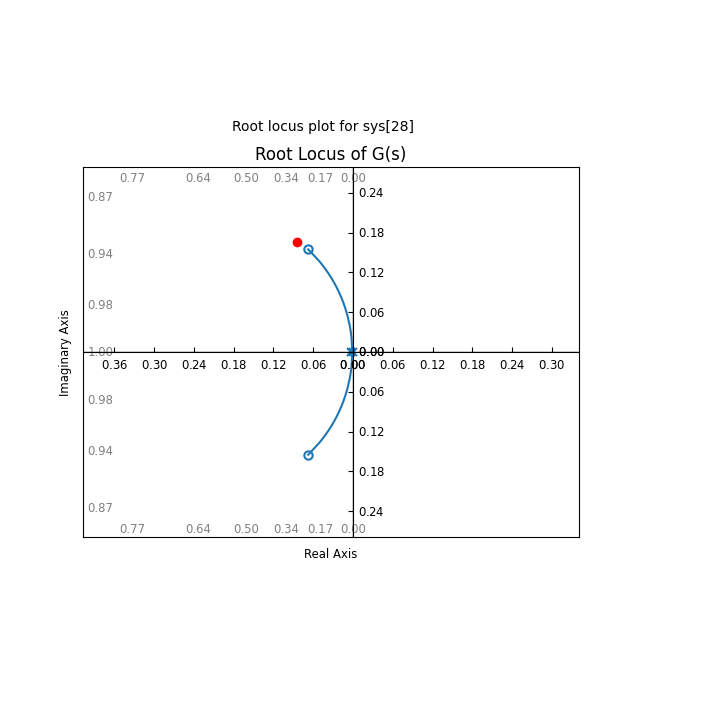

In [28]:
# Plotando RL com ponto dejado de mapear
plt.figure()
ct.root_locus(C*G)
plt.plot(sigma_i, w_i, 'ro')
plt.title('Root Locus of G(s)')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.grid()
plt.show()

In [29]:
# Calculo das informações da respota ao degrau da T(s)
step_info_T = ct.step_info(T)

# Extraindo e plotando as especifiçãoes da função ct.step_info
print(f"Tr: {step_info_T['RiseTime']:.2f} s")
print(f"Tp: {step_info_T['PeakTime']:.2f} s")
print(f"Mp: {step_info_T['Overshoot']:.2f}%")
print(f"Ts: {step_info_T['SettlingTime']:.2f} s (2% tolerancia)")
print(f"theta_rp: {step_info_T['SteadyStateValue']:.2f}")

Tr: 207.66 s
Tp: 539.91 s
Mp: 51.25%
Ts: 2865.69 s (2% tolerancia)
theta_rp: 1.00


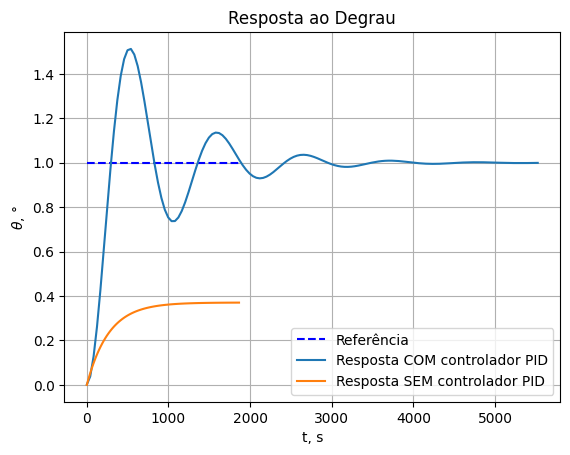

In [32]:
# Plotando noo gráfico as curvas com controlador PID, sem controlador PID e referncia
t_t, theta_t = ct.step_response(T)
step = np.ones_like(t_t1) * 1.0 # Define a reference step signal of amplitude 1.0

plt.figure()
plt.plot(t_t1, step, 'b--', label='Referência') # Plot the reference step
plt.plot(t_t, theta_t, label='Resposta COM controlador PID')
plt.plot(t_t1, theta_t1, label='Resposta SEM controlador PID')
plt.xlabel('t, s')
plt.ylabel(r'$\theta$, °')
plt.legend(loc='lower right')
plt.grid()
plt.xlim()
plt.title('Resposta ao Degrau')
plt.show()

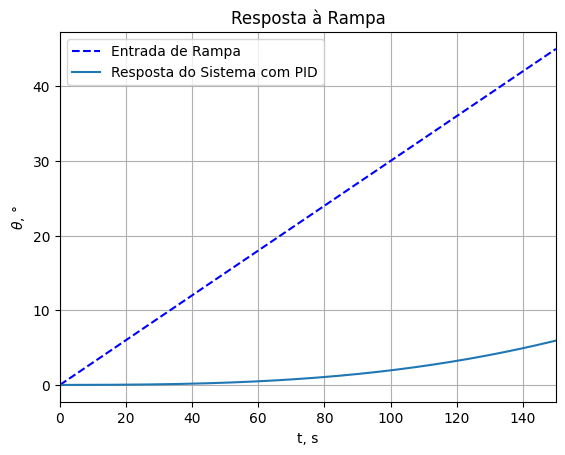

Erro_RP: 39.07


In [31]:
# Definir o coeficiente angular da rampa
theta_ref = 30
t_ref = 100
coef_angular = theta_ref / t_ref

# Gerar o sinal de rampa
t_ramp = np.linspace(0, 150, 1000) # Usar o mesmo intervalo de tempo dos outros gráficos
ramp_input = coef_angular * t_ramp

# Calcular a resposta do sistema (T) à entrada de rampa
t_out_ramp, y_out_ramp = ct.forced_response(T, T=t_ramp, U=ramp_input)

# Plotar a resposta à rampa
plt.figure()
plt.plot(t_ramp, ramp_input, 'b--', label='Entrada de Rampa')
plt.plot(t_out_ramp, y_out_ramp, '', label='Resposta do Sistema com PID')
plt.xlabel('t, s')
plt.ylabel(r'$\theta$, °')
plt.legend(loc='upper left')
plt.grid(True)
plt.title('Resposta à Rampa')
plt.xlim(0, 150)
plt.show()

# Erro de regime permanente
erro_T_rampa = ramp_input[-1] - y_out_ramp[-1]
print(f"Erro_RP: {erro_T_rampa:.2f}")